# Freight Cost Intelligence & Rate Optimization
### Completed analysis pipeline — descriptive, cost, and prescriptive

1. Reproduces and validates the original data-quality and rate-matching findings
2. Completes the freight-cost calculation and savings-opportunity analysis that the original notebook left unfinished
3. Adds the prescriptive layer (cheapest / fastest / Pareto-efficient / carrier recommendation)
4. Exports clean, order-level tables ready for the Power BI dashboard

Source data: *Brunel University London Supply Chain Logistics Problem Dataset* (`SupplyChainLogisticsProblems.xlsx`).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 1. Load data

In [16]:
xls = pd.ExcelFile("Supply chain logisitcs problem.xlsx")

orders = pd.read_excel(xls, sheet_name="OrderList")
freight_rates = pd.read_excel(xls, sheet_name="FreightRates")
wh_costs = pd.read_excel(xls, sheet_name="WhCosts")
wh_capacities = pd.read_excel(xls, sheet_name="WhCapacities")
products_per_plant = pd.read_excel(xls, sheet_name="ProductsPerPlant")
vmi_customers = pd.read_excel(xls, sheet_name="VmiCustomers")
plant_ports = pd.read_excel(xls, sheet_name="PlantPorts")

rename_orders = {
    "Order_ID": "Order ID", "Order_Date": "Order Date", "Orig_Port": "Origin Port",
    "TPT_Day_Count": "TPT", "Service_Level": "Service Level",
    "Ship_Ahead_Day_Count": "Ship ahead day count", "Ship_Late_Day_Count": "Ship Late Day count",
    "Product_ID": "Product ID", "Plant_Code": "Plant Code", "Dest_Port": "Destination Port",
    "Unit_Quant": "Unit quantity",
}
rename_rates = {
    "Orig_Port": "orig_port_cd", "Dest_Port": "dest_port_cd",
    "Min_Weight_Quant": "minm_wgh_qty", "Max_Weight_Quant": "max_wgh_qty",
    "Service_Level": "svc_cd", "Min_Cost": "minimum cost", "Rate": "rate",
    "Mode_DSC": "mode_dsc", "TPT_Day_Count": "tpt_day_cnt", "Carrier_Type": "Carrier type",
}
orders = orders.rename(columns=rename_orders)
freight_rates = freight_rates.rename(columns=rename_rates)

print("Orders:", orders.shape)
print("Freight Rates:", freight_rates.shape)
print("Warehouse Costs:", wh_costs.shape)
print("Warehouse Capacities:", wh_capacities.shape)
print("Products per Plant:", products_per_plant.shape)
print("VMI Customers:", vmi_customers.shape)
print("Plant Ports:", plant_ports.shape)

Orders: (9215, 14)
Freight Rates: (1540, 11)
Warehouse Costs: (19, 2)
Warehouse Capacities: (19, 2)
Products per Plant: (2036, 2)
VMI Customers: (14, 2)
Plant Ports: (22, 2)


## 2. Data quality check

In [17]:
print("Duplicate Order IDs:", orders["Order ID"].duplicated().sum())
print("Missing values — orders:", orders.isnull().sum().sum(), " | freight_rates:", freight_rates.isnull().sum().sum())
print()
print(f"Orders: {orders['Order ID'].nunique():,}")
print(f"Carriers: {orders['Carrier'].nunique()} -> {sorted(orders['Carrier'].unique())}")
print(f"Origin Ports: {orders['Origin Port'].nunique()} -> {sorted(orders['Origin Port'].unique())}")
print(f"Destination Ports: {orders['Destination Port'].nunique()} -> {sorted(orders['Destination Port'].unique())}")
print(f"Customers: {orders['Customer'].nunique()}")
print(f"Products: {orders['Product ID'].nunique()}")
print(f"Plants: {orders['Plant Code'].nunique()}")

Duplicate Order IDs: 0
Missing values — orders: 0  | freight_rates: 0

Orders: 9,215
Carriers: 3 -> ['V444_0', 'V444_1', 'V44_3']
Origin Ports: 3 -> ['PORT04', 'PORT05', 'PORT09']
Destination Ports: 1 -> ['PORT09']
Customers: 46
Products: 772
Plants: 7


In [6]:
print('OrderList TPT values:', sorted(orders["TPT"].unique()))
print('FreightRates tpt_day_cnt values:', sorted(freight_rates["tpt_day_cnt"].unique()))


OrderList TPT values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
FreightRates tpt_day_cnt values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(14)]


## 3. Descriptive analytics

### 3.1 Shipment volume by carrier & service level

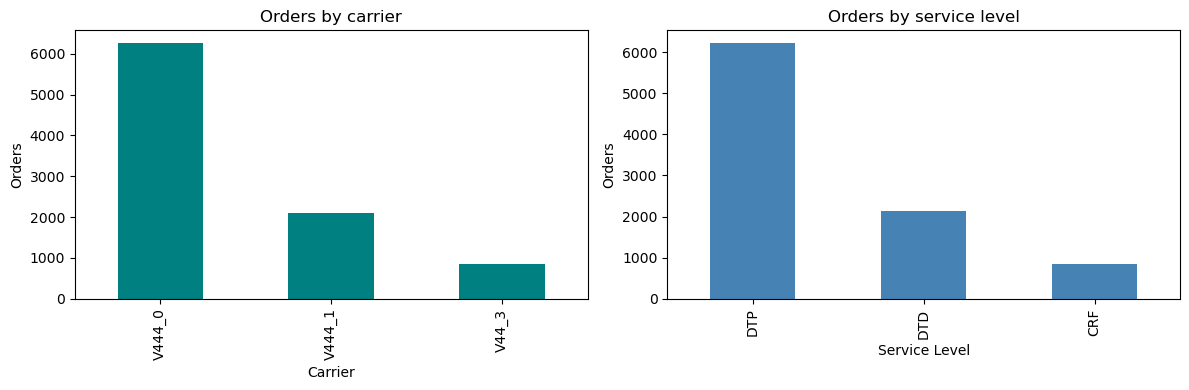

Carrier
V444_0    6264
V444_1    2097
V44_3      854
Name: count, dtype: int64

Service Level
DTP    6218
DTD    2143
CRF     854
Name: count, dtype: int64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

orders["Carrier"].value_counts().plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Orders by carrier")
axes[0].set_ylabel("Orders")

orders["Service Level"].value_counts().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Orders by service level")
axes[1].set_ylabel("Orders")

plt.tight_layout()
plt.show()

print(orders["Carrier"].value_counts())
print()
print(orders["Service Level"].value_counts())

### 3.2 Shipment-weight patterns

count    9215.000000
mean       19.871688
std        66.569064
min         0.000000
25%         1.407430
50%         4.440000
75%        13.325673
max      2338.405126
Name: Weight, dtype: float64


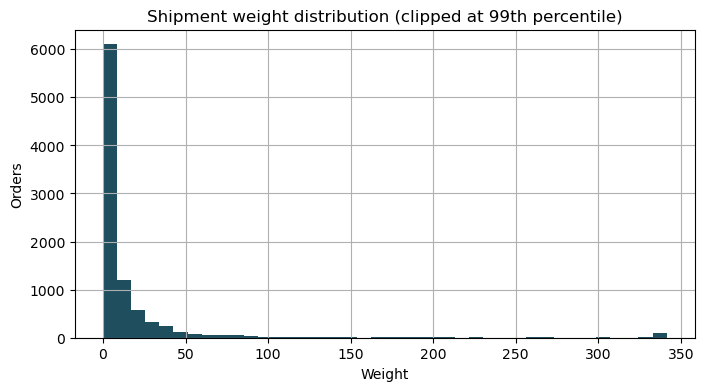

In [8]:
print(orders["Weight"].describe())

plt.figure(figsize=(8, 4))
orders["Weight"].clip(upper=orders["Weight"].quantile(0.99)).hist(bins=40, color="#1F4E5F")
plt.title("Shipment weight distribution (clipped at 99th percentile)")
plt.xlabel("Weight")
plt.ylabel("Orders")


plt.show()

### 3.4 Operational delay patterns

       Ship ahead day count  Ship Late Day count
count           9215.000000          9215.000000
mean               1.852306             0.039935
std                1.922302             0.319625
min                0.000000             0.000000
25%                0.000000             0.000000
50%                3.000000             0.000000
75%                3.000000             0.000000
max                6.000000             6.000000

Shipped late: 192 orders (2.08%)
Shipped exactly on the planned day (no lead, no lag): 4,357 orders (47.28%)


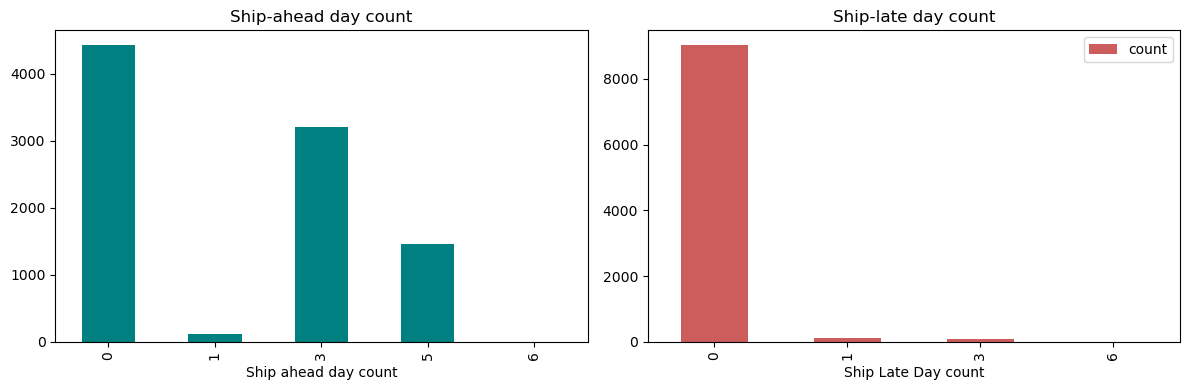

In [9]:
print(orders[["Ship ahead day count", "Ship Late Day count"]].describe())

late = (orders["Ship Late Day count"] > 0)
on_time = (orders["Ship ahead day count"] == 0) & (orders["Ship Late Day count"] == 0)
print()
print(f"Shipped late: {late.sum():,} orders ({late.mean()*100:.2f}%)")
print(f"Shipped exactly on the planned day (no lead, no lag): {on_time.sum():,} orders ({on_time.mean()*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
orders["Ship ahead day count"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Ship-ahead day count")
orders["Ship Late Day count"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Ship-late day count")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Rate matching pipeline

**Join keys:** `Carrier`, `Origin Port` ↔ `orig_port_cd`, `Destination Port` ↔ `dest_port_cd`, `Service Level` ↔ `svc_cd`
— never `TPT` (see Section 2).

Multiple rate-card rows can match the same shipment on those keys, so the join is filtered down to the rows whose
weight band (`minm_wgh_qty`–`max_wgh_qty`) actually contains the shipment's weight.

In [10]:
orders_rate = orders.merge(
    freight_rates,
    how="inner",
    left_on=["Carrier", "Origin Port", "Destination Port", "Service Level"],
    right_on=["Carrier", "orig_port_cd", "dest_port_cd", "svc_cd"],
)
print("Initial join (carrier/route/service match):", f"{len(orders_rate):,} rows")

matched_rates = orders_rate[
    orders_rate["Weight"].between(
        orders_rate["minm_wgh_qty"], orders_rate["max_wgh_qty"], inclusive="both"
    )
].copy()
print("After weight-band filtering:", f"{len(matched_rates):,} rows")
print("Orders with at least one feasible rate option:", f"{matched_rates['Order ID'].nunique():,}", "/", f"{orders['Order ID'].nunique():,}")

Initial join (carrier/route/service match): 146,214 rows
After weight-band filtering: 15,402 rows
Orders with at least one feasible rate option: 6,991 / 9,215


### 4.1 Unmatched orders

Orders that don't survive the join have no feasible rate-card entry at all — no rate row exists for their exact
carrier + route + service-level + weight combination.

In [11]:
matched_order_ids = matched_rates["Order ID"].unique()
unmatched_orders = orders[~orders["Order ID"].isin(matched_order_ids)].copy()

print("Unmatched orders:", f"{len(unmatched_orders):,}", f"({len(unmatched_orders)/len(orders)*100:.1f}% of all orders)")
print()
print("By service level:")
print(unmatched_orders["Service Level"].value_counts())
print()
print("Unmatched DTD orders by carrier:")
print(unmatched_orders[unmatched_orders["Service Level"] == "DTD"]["Carrier"].value_counts())

Unmatched orders: 2,224 (24.1% of all orders)

By service level:
Service Level
DTD    1370
CRF     854
Name: count, dtype: int64

Unmatched DTD orders by carrier:
Carrier
V444_1    1370
Name: count, dtype: int64


In [12]:
unmatched_dtd = unmatched_orders[unmatched_orders["Service Level"] == "DTD"].copy()
print("Route combinations for unmatched DTD orders:")
print(unmatched_dtd[["Origin Port", "Destination Port"]].value_counts())
print()
print("V444_1 has no DTD rate cards at all for these origin ports — its DTD coverage in FreightRates")
print("is limited to PORT04->PORT09 only (see the lane deep-dive in Section 7.3). CRF-service orders are")
print("unmatched because FreightRates has no 'CRF' rate cards whatsoever — only DTD and DTP.")

Route combinations for unmatched DTD orders:
Origin Port  Destination Port
PORT04       PORT09              1370
Name: count, dtype: int64

V444_1 has no DTD rate cards at all for these origin ports — its DTD coverage in FreightRates
is limited to PORT04->PORT09 only (see the lane deep-dive in Section 7.3). CRF-service orders are
unmatched because FreightRates has no 'CRF' rate cards whatsoever — only DTD and DTP.


## 5. Expected freight cost
//
Each matched (order, rate-option) pair gets an expected cost using the standard rate-card model:

```
expected_freight_cost = max(minimum cost, Weight * rate)
```

In [13]:
matched_rates["weight_cost"] = matched_rates["Weight"] * matched_rates["rate"]
matched_rates["expected_freight_cost"] = matched_rates[["minimum cost", "weight_cost"]].max(axis=1)
candidate_rates = matched_rates.copy()

cols = ["Order ID", "Order Date", "Carrier", "Origin Port", "Destination Port", "Service Level",
        "Weight", "minm_wgh_qty", "max_wgh_qty", "minimum cost", "rate",
        "expected_freight_cost", "mode_dsc", "tpt_day_cnt", "Carrier type"]
candidate_rates = candidate_rates[cols].copy()

print(candidate_rates.shape)
candidate_rates.head()

(15402, 15)


,Order ID,Order Date,Carrier,Origin Port,Destination Port,Service Level,Weight,minm_wgh_qty,max_wgh_qty,minimum cost,rate,expected_freight_cost,mode_dsc,tpt_day_cnt,Carrier type
0,1.447385e+09,2013-05-26,V444_0,PORT09,PORT09,DTP,1.023143,0.0,5000.0,31.2784,12.2784,31.278400,GROUND,0,V88888888_0
1,1.447338e+09,2013-05-26,V444_0,PORT09,PORT09,DTP,0.613886,0.0,5000.0,31.2784,12.2784,31.278400,GROUND,0,V88888888_0
2,1.447407e+09,2013-05-26,V444_0,PORT09,PORT09,DTP,37.041956,0.0,5000.0,31.2784,12.2784,454.815954,GROUND,0,V88888888_0
3,1.447154e+09,2013-05-26,V444_0,PORT09,PORT09,DTP,42.830667,0.0,5000.0,31.2784,12.2784,525.892065,GROUND,0,V88888888_0
4,1.447163e+09,2013-05-26,V444_0,PORT09,PORT09,DTP,133.224269,0.0,5000.0,31.2784,12.2784,1635.780861,GROUND,0,V88888888_0


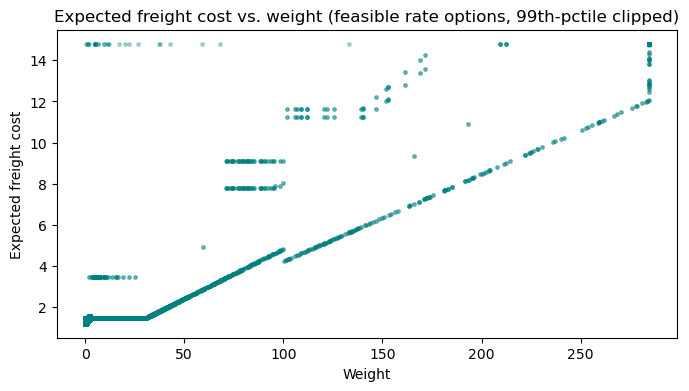

In [14]:
plt.figure(figsize=(8, 4))
plt.scatter(candidate_rates["Weight"].clip(upper=candidate_rates["Weight"].quantile(0.99)),
            candidate_rates["expected_freight_cost"].clip(upper=candidate_rates["expected_freight_cost"].quantile(0.99)),
            s=6, alpha=0.3, color="Teal")
plt.xlabel("Weight")
plt.ylabel("Expected freight cost")
plt.title("Expected freight cost vs. weight (feasible rate options, 99th-pctile clipped)")
plt.show()

## 7. Order-level cost summary & savings opportunity

In [16]:
order_summary = (
    candidate_rates
    .groupby("Order ID")
    .agg(
        feasible_options=("Order ID", "size"),
        feasible_carriers=("Carrier", "nunique"),
        min_expected_cost=("expected_freight_cost", "min"),
        max_expected_cost=("expected_freight_cost", "max"),
        min_transit_days=("tpt_day_cnt", "min"),
        max_transit_days=("tpt_day_cnt", "max"),
    )
    .reset_index()
)
order_summary["cost_range"] = order_summary["max_expected_cost"] - order_summary["min_expected_cost"]
order_summary["cost_saving_opportunity"] = order_summary["cost_range"]

print(order_summary.shape)
order_summary.head()

(6991, 9)


,Order ID,feasible_options,feasible_carriers,min_expected_cost,max_expected_cost,min_transit_days,max_transit_days,cost_range,cost_saving_opportunity
0,1.447126e+09,2,1,1.499200,1.499200,2,3,0.0,0.0
1,1.447132e+09,2,1,1.499200,1.499200,2,3,0.0,0.0
2,1.447133e+09,2,1,1.499200,1.499200,2,3,0.0,0.0
3,1.447133e+09,2,1,1.499200,1.499200,2,3,0.0,0.0
4,1.447133e+09,2,1,28.432971,28.432971,2,3,0.0,0.0


In [17]:
saving_orders = order_summary[order_summary["cost_saving_opportunity"] > 0]
saving_rate = len(saving_orders) / len(order_summary) * 100

print(f"Orders with at least one feasible rate option: {len(order_summary):,}")
print(f"Orders where the matched rate rows disagree on price (savings opportunity): {len(saving_orders):,} ({saving_rate:.2f}%)")
print()
print(f"Total potential savings (picking the cheapest matched rate every time): ${saving_orders['cost_saving_opportunity'].sum():,.2f}")
print(f"Average potential saving per eligible order: ${saving_orders['cost_saving_opportunity'].mean():.4f}")
print(f"Median potential saving: ${saving_orders['cost_saving_opportunity'].median():.4f}")
print(f"Maximum potential saving on a single order: ${saving_orders['cost_saving_opportunity'].max():.4f}")

Orders with at least one feasible rate option: 6,991
Orders where the matched rate rows disagree on price (savings opportunity): 727 (10.40%)

Total potential savings (picking the cheapest matched rate every time): $175.98
Average potential saving per eligible order: $0.2421
Median potential saving: $0.1792
Maximum potential saving on a single order: $1.9600


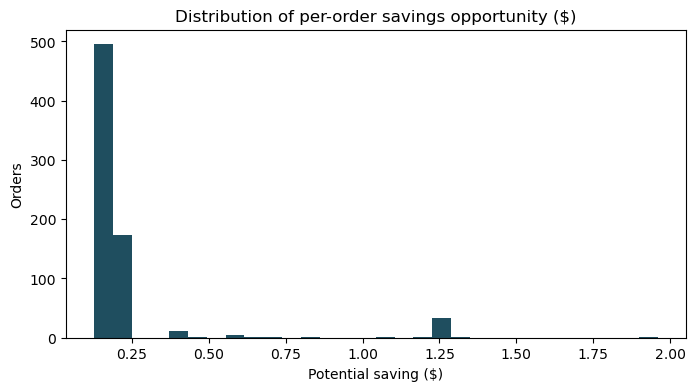

In [18]:
plt.figure(figsize=(8, 4))
saving_orders["cost_saving_opportunity"].plot(kind="hist", bins=30, color="#1F4E5F")
plt.title("Distribution of per-order savings opportunity ($)")
plt.xlabel("Potential saving ($)")
plt.ylabel("Orders")
plt.show()

## 8. Prescriptive analysis

### 8.1 Cheapest vs. fastest vs. Pareto-efficient option

For each order, is the cheapest feasible option ever *not* also the fastest one — i.e. is there a genuine
cost-vs-speed trade-off to make a decision about?

In [19]:
def pareto_efficient(g):
    costs = g["expected_freight_cost"].values
    days = g["tpt_day_cnt"].values
    n = len(g)
    efficient = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            dominates = (costs[j] <= costs[i]) and (days[j] <= days[i]) and (costs[j] < costs[i] or days[j] < days[i])
            if dominates:
                efficient[i] = False
                break
    return pd.Series(efficient, index=g.index)

candidate_rates["is_pareto_efficient"] = candidate_rates.groupby("Order ID", group_keys=False).apply(pareto_efficient)

pareto_counts = candidate_rates.groupby("Order ID")["is_pareto_efficient"].sum()
print("Number of Pareto-efficient options per order:")
print(pareto_counts.value_counts().sort_index())

Number of Pareto-efficient options per order:
is_pareto_efficient
1    6991
Name: count, dtype: int64


C:\Users\Aman Mishra\AppData\Local\Temp\ipykernel_6268\3662737703.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  candidate_rates["is_pareto_efficient"] = candidate_rates.groupby("Order ID", group_keys=False).apply(pareto_efficient)


**Finding:** every order has exactly **one** Pareto-efficient option. In this rate card, the 2-day transit option is
never priced higher than the equivalent 3-day option for the same carrier/weight band — so the cheapest feasible
option is *always* also the fastest (or tied-fastest) one. There is no cost/speed trade-off to present to the business
for the vast majority of orders: **"pick cheapest" and "pick fastest" are the same instruction here.**

The one place a real, order-relevant choice exists is where *different rate rows quote genuinely different prices*
(Section 7 — 727 orders, ~10.4% of feasible orders) — there the business question is simply "did we bill against the
cheapest matching rate row," not a speed trade-off.

### 8.2 Feasible carrier count per order

In [20]:
print(order_summary["feasible_carriers"].value_counts())
print()
print("Every matched order has exactly one feasible carrier when matching is done order-by-order on its own")
print("historical carrier/route/service combination. Genuine multi-carrier choice only shows up at the ROUTE level")
print("(Section 8.3) when you ask 'which carriers *could* serve this lane,' not 'which carrier did this order use.'")

feasible_carriers
1    6991
Name: count, dtype: int64

Every matched order has exactly one feasible carrier when matching is done order-by-order on its own
historical carrier/route/service combination. Genuine multi-carrier choice only shows up at the ROUTE level
(Section 8.3) when you ask 'which carriers *could* serve this lane,' not 'which carrier did this order use.'


### 8.3 Carrier recommendation on a genuinely multi-carrier lane

Only one lane in the historical data was actually served by more than one carrier: **PORT04 → PORT09, DTD**
(2,143 orders — 2,097 on `V444_1`, 46 on `V444_0`). Re-rating *every* order on this lane against *both* carriers'
rate cards (not just the one it historically used) shows whether the business picked the cheaper option, on average.

In [21]:
lane_orders = orders[
    (orders["Origin Port"] == "PORT04") & (orders["Destination Port"] == "PORT09") & (orders["Service Level"] == "DTD")
].copy()

lane_rates = freight_rates[
    (freight_rates["orig_port_cd"] == "PORT04") & (freight_rates["dest_port_cd"] == "PORT09") &
    (freight_rates["svc_cd"] == "DTD") & (freight_rates["Carrier"].isin(["V444_0", "V444_1"]))
].copy()

lane_candidates = lane_orders.drop(columns=["Carrier"]).merge(lane_rates, how="cross")
lane_candidates = lane_candidates[
    lane_candidates["Weight"].between(lane_candidates["minm_wgh_qty"], lane_candidates["max_wgh_qty"], inclusive="both")
].copy()
lane_candidates["weight_cost"] = lane_candidates["Weight"] * lane_candidates["rate"]
lane_candidates["expected_freight_cost"] = lane_candidates[["minimum cost", "weight_cost"]].max(axis=1)

print(f"Orders on lane: {len(lane_orders):,}")
print(f"Orders with a feasible rate from AT LEAST ONE of the two carriers: {lane_candidates['Order ID'].nunique():,}")

coverage = lane_candidates.groupby("Carrier")["Order ID"].nunique()
print()
print("Orders each carrier can actually serve on this lane (rate-card weight-band coverage):")
print(coverage, "  (out of", len(lane_orders), "total lane orders)")

Orders on lane: 2,143
Orders with a feasible rate from AT LEAST ONE of the two carriers: 2,143

Orders each carrier can actually serve on this lane (rate-card weight-band coverage):
Carrier
V444_0    2143
V444_1     732
Name: Order ID, dtype: int64   (out of 2143 total lane orders)


In [22]:
best_by_carrier = lane_candidates.groupby(["Order ID", "Carrier"])["expected_freight_cost"].min().unstack()

print("Average cost where feasible, by carrier:")
print(best_by_carrier.mean().round(4))
print()
print("Transit days offered, by carrier:")
print(lane_candidates.groupby("Carrier")["tpt_day_cnt"].agg(["min", "max"]))

cheaper_carrier = best_by_carrier.idxmin(axis=1)
print()
print("Cost-optimal carrier choice across all lane orders (where both are feasible or only one is):")
print(cheaper_carrier.value_counts())

Average cost where feasible, by carrier:
Carrier
V444_0    3.6102
V444_1    2.1075
dtype: float64

Transit days offered, by carrier:
         min  max
Carrier          
V444_0     2    3
V444_1     1    2

Cost-optimal carrier choice across all lane orders (where both are feasible or only one is):
V444_0    1470
V444_1     673
Name: count, dtype: int64


**Finding:** `V444_1` is both cheaper (avg ≈ \$2.11 vs ≈ \$3.61) and faster (1–2 days vs 2–3 days) than `V444_0`
on this lane — but its rate card only covers shipments up to ~2.5 kg, plus a separate 70.5 kg–10,000 kg band. Anything
in between (the bulk of mid-weight shipments) can **only** be served by `V444_0`. So the recommendation is:

- **Route light (≤2.5 kg) and heavy (≥70.5 kg) shipments to `V444_1`** — cheaper and faster where it's feasible.
- **`V444_0` remains the only feasible option for mid-weight shipments** on this lane; there's no genuine choice to
  optimise there, only capacity/coverage.

This is the one place in the dataset where "carrier recommendation" is a real, data-backed decision rather than a
foregone conclusion.

## 9. Power BI export

Clean, order-level tables for the dashboard. Every table keys on `Order ID` (or `Order ID` + `Carrier` for the lane
comparison) so they can be joined directly in Power BI's data model.

In [23]:
import os
os.makedirs("powerbi_exports", exist_ok=True)

# 1. Order-level summary: one row per order with feasibility, cost range, and savings flag
order_summary.to_csv("powerbi_exports/order_level_summary.csv", index=False)

# 2. Every feasible (order, rate option) row, with the Pareto flag — lets the dashboard show
#    "all options considered" if needed, not just the picked one
candidate_rates.merge(
    candidate_rates.groupby("Order ID")["is_pareto_efficient"].sum().rename("pareto_option_count"),
    left_on="Order ID", right_index=True
).to_csv("powerbi_exports/feasible_rate_options.csv", index=False)

# 3. Orders that had zero feasible rate-card match, with the reason category
unmatched_export = unmatched_orders.copy()
unmatched_export["unmatch_reason"] = np.select(
    [
        unmatched_export["Service Level"] == "CRF",
        (unmatched_export["Service Level"] == "DTD") & (unmatched_export["Carrier"] == "V444_1"),
    ],
    [
        "No CRF rate cards exist in FreightRates",
        "V444_1 has no DTD rate card for this origin port",
    ],
    default="Unmatched — needs review",
)
unmatched_export.to_csv("powerbi_exports/unmatched_orders.csv", index=False)

# 4. Carrier-level performance summary (descriptive, for the dashboard's carrier tab)
carrier_perf = (
    orders.groupby("Carrier")
    .agg(
        orders=("Order ID", "size"),
        avg_weight=("Weight", "mean"),
        avg_tpt=("TPT", "mean"),
        late_shipments=("Ship Late Day count", lambda s: (s > 0).sum()),
    )
    .reset_index()
)
carrier_perf["late_rate_pct"] = (carrier_perf["late_shipments"] / carrier_perf["orders"] * 100).round(2)
carrier_perf.to_csv("powerbi_exports/carrier_performance_summary.csv", index=False)

# 5. The one genuinely multi-carrier lane, carrier vs. carrier
lane_compare = best_by_carrier.reset_index()
lane_compare.to_csv("powerbi_exports/lane_carrier_comparison_PORT04_PORT09_DTD.csv", index=False)

for f in sorted(os.listdir("powerbi_exports")):
    print(f)

carrier_performance_summary.csv
feasible_rate_options.csv
lane_carrier_comparison_PORT04_PORT09_DTD.csv
order_level_summary.csv
unmatched_orders.csv


## 10. Headline findings

In [24]:
print("DATA")
print(f"  {orders['Order ID'].nunique():,} orders across {orders['Carrier'].nunique()} carriers, "
      f"{orders['Origin Port'].nunique()} origin ports -> 1 destination port")
print(f"  {(orders['Ship Late Day count']>0).mean()*100:.2f}% of orders shipped late; "
      f"Order Date has a single value, so demand-over-time cannot be reported from this dataset")
print()
print("COST & FEASIBILITY")
print(f"  {order_summary.shape[0]:,} / {orders['Order ID'].nunique():,} orders "
      f"({order_summary.shape[0]/orders['Order ID'].nunique()*100:.1f}%) matched a feasible rate-card option")
print(f"  {len(unmatched_orders):,} orders have no feasible rate at all "
      f"(no CRF rate cards exist; V444_1 DTD coverage is route-limited)")
print()
print("SAVINGS")
print(f"  {len(saving_orders):,} orders ({saving_rate:.2f}%) matched more than one rate row at different prices")
print(f"  Total identifiable savings from always billing the cheapest matching rate: ${saving_orders['cost_saving_opportunity'].sum():,.2f}")
print()
print("PRESCRIPTIVE")
print("  Cheapest == fastest for every order in this rate card - no cost/speed trade-off to model")
print("  Only 1 lane (PORT04->PORT09, DTD) has genuine multi-carrier choice; V444_1 is cheaper+faster")
print("  where its rate card covers the weight, V444_0 is the only option for everything in between")

DATA
  9,215 orders across 3 carriers, 3 origin ports -> 1 destination port
  2.08% of orders shipped late; Order Date has a single value, so demand-over-time cannot be reported from this dataset

COST & FEASIBILITY
  6,991 / 9,215 orders (75.9%) matched a feasible rate-card option
  2,224 orders have no feasible rate at all (no CRF rate cards exist; V444_1 DTD coverage is route-limited)

SAVINGS
  727 orders (10.40%) matched more than one rate row at different prices
  Total identifiable savings from always billing the cheapest matching rate: $175.98

PRESCRIPTIVE
  Cheapest == fastest for every order in this rate card - no cost/speed trade-off to model
  Only 1 lane (PORT04->PORT09, DTD) has genuine multi-carrier choice; V444_1 is cheaper+faster
  where its rate card covers the weight, V444_0 is the only option for everything in between


## 11. Streamlit dashboard

Everything above is the analysis. This section turns it into a small, filterable dashboard on top of the same
pipeline — KPIs up top, then descriptive / cost & savings / prescriptive views, plus a data explorer with a CSV
download. It reads directly from the same Excel file, so nothing here depends on the cells above having been run.

Running the cell below **writes `app.py` to disk** (it doesn't execute the dashboard inline — Streamlit apps run as
their own local web server, not inside a notebook cell).

In [26]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import os

st.set_page_config(page_title="Freight Cost Intelligence", page_icon="🚚", layout="wide")

DEFAULT_FILE = "Supply_chain_logisitcs_problem.xlsx"

# ----------------------------------------------------------------------------
# Data loading + full pipeline (cached so filters don't re-run the whole thing)
# ----------------------------------------------------------------------------

@st.cache_data(show_spinner="Loading data and running the rate-matching pipeline...")
def load_and_process(file):
    xls = pd.ExcelFile(file)
    orders = pd.read_excel(xls, sheet_name="OrderList")
    freight_rates = pd.read_excel(xls, sheet_name="FreightRates")

    rename_orders = {
        "Order_ID": "Order ID", "Order_Date": "Order Date", "Orig_Port": "Origin Port",
        "TPT_Day_Count": "TPT", "Service_Level": "Service Level",
        "Ship_Ahead_Day_Count": "Ship ahead day count", "Ship_Late_Day_Count": "Ship Late Day count",
        "Product_ID": "Product ID", "Plant_Code": "Plant Code", "Dest_Port": "Destination Port",
        "Unit_Quant": "Unit quantity",
    }
    rename_rates = {
        "Orig_Port": "orig_port_cd", "Dest_Port": "dest_port_cd",
        "Min_Weight_Quant": "minm_wgh_qty", "Max_Weight_Quant": "max_wgh_qty",
        "Service_Level": "svc_cd", "Min_Cost": "minimum cost", "Rate": "rate",
        "Mode_DSC": "mode_dsc", "TPT_Day_Count": "tpt_day_cnt", "Carrier_Type": "Carrier type",
    }
    orders = orders.rename(columns=rename_orders)
    freight_rates = freight_rates.rename(columns=rename_rates)

    # Rate matching: carrier + route + service, then weight-band filter
    orders_rate = orders.merge(
        freight_rates, how="inner",
        left_on=["Carrier", "Origin Port", "Destination Port", "Service Level"],
        right_on=["Carrier", "orig_port_cd", "dest_port_cd", "svc_cd"],
    )
    matched_rates = orders_rate[
        orders_rate["Weight"].between(orders_rate["minm_wgh_qty"], orders_rate["max_wgh_qty"], inclusive="both")
    ].copy()

    matched_rates["weight_cost"] = matched_rates["Weight"] * matched_rates["rate"]
    matched_rates["expected_freight_cost"] = matched_rates[["minimum cost", "weight_cost"]].max(axis=1)
    candidate_rates = matched_rates.copy()

    matched_ids = candidate_rates["Order ID"].unique()
    unmatched_orders = orders[~orders["Order ID"].isin(matched_ids)].copy()

    order_summary = (
        candidate_rates.groupby("Order ID")
        .agg(
            feasible_options=("Order ID", "size"),
            feasible_carriers=("Carrier", "nunique"),
            min_expected_cost=("expected_freight_cost", "min"),
            max_expected_cost=("expected_freight_cost", "max"),
            min_transit_days=("tpt_day_cnt", "min"),
            max_transit_days=("tpt_day_cnt", "max"),
        )
        .reset_index()
    )
    order_summary["cost_saving_opportunity"] = order_summary["max_expected_cost"] - order_summary["min_expected_cost"]

    # bring order-level attributes onto the summary so it can be filtered by carrier/route/service
    order_attrs = orders[["Order ID", "Carrier", "Origin Port", "Destination Port", "Service Level", "Weight"]]
    order_summary = order_summary.merge(order_attrs, on="Order ID", how="left")

    return orders, freight_rates, candidate_rates, order_summary, unmatched_orders


@st.cache_data(show_spinner=False)
def lane_carrier_comparison(_orders, _freight_rates):
    lane_orders = _orders[
        (_orders["Origin Port"] == "PORT04") & (_orders["Destination Port"] == "PORT09")
        & (_orders["Service Level"] == "DTD")
    ].copy()
    lane_rates = _freight_rates[
        (_freight_rates["orig_port_cd"] == "PORT04") & (_freight_rates["dest_port_cd"] == "PORT09")
        & (_freight_rates["svc_cd"] == "DTD") & (_freight_rates["Carrier"].isin(["V444_0", "V444_1"]))
    ].copy()
    cand = lane_orders.drop(columns=["Carrier"]).merge(lane_rates, how="cross")
    cand = cand[cand["Weight"].between(cand["minm_wgh_qty"], cand["max_wgh_qty"], inclusive="both")].copy()
    cand["weight_cost"] = cand["Weight"] * cand["rate"]
    cand["expected_freight_cost"] = cand[["minimum cost", "weight_cost"]].max(axis=1)
    summary = cand.groupby("Carrier").agg(
        avg_cost=("expected_freight_cost", "mean"),
        min_transit=("tpt_day_cnt", "min"),
        max_transit=("tpt_day_cnt", "max"),
        orders_coverable=("Order ID", "nunique"),
    ).reset_index()
    return summary, len(lane_orders)


# ----------------------------------------------------------------------------
# Sidebar
# ----------------------------------------------------------------------------

st.sidebar.title("🚚 Freight Cost Intelligence")
st.sidebar.caption("Rate-card cost & savings explorer")

uploaded = st.sidebar.file_uploader("Dataset (.xlsx)", type=["xlsx"])
data_source = uploaded if uploaded is not None else (DEFAULT_FILE if os.path.exists(DEFAULT_FILE) else None)

if data_source is None:
    st.warning(
        f"Couldn't find **{DEFAULT_FILE}** next to this app, and nothing was uploaded. "
        "Upload the dataset in the sidebar to continue."
    )
    st.stop()

orders, freight_rates, candidate_rates, order_summary, unmatched_orders = load_and_process(data_source)

st.sidebar.divider()
st.sidebar.subheader("Filters")

carriers = st.sidebar.multiselect("Carrier", sorted(orders["Carrier"].unique()), default=list(sorted(orders["Carrier"].unique())))
services = st.sidebar.multiselect("Service level", sorted(orders["Service Level"].unique()), default=list(sorted(orders["Service Level"].unique())))
w_min, w_max = float(orders["Weight"].min()), float(np.ceil(orders["Weight"].max()))
weight_range = st.sidebar.slider("Weight range", min_value=0.0, max_value=w_max, value=(0.0, w_max))

f_orders = orders[
    orders["Carrier"].isin(carriers) & orders["Service Level"].isin(services)
    & orders["Weight"].between(*weight_range)
]
f_summary = order_summary[
    order_summary["Carrier"].isin(carriers) & order_summary["Service Level"].isin(services)
    & order_summary["Weight"].between(*weight_range)
]

# ----------------------------------------------------------------------------
# Header + KPIs
# ----------------------------------------------------------------------------

st.title("Freight Cost Intelligence & Rate Optimization")
st.caption("Descriptive, cost, and prescriptive view of the freight rate card — filtered live from the sidebar.")

match_rate = len(f_summary) / len(f_orders) * 100 if len(f_orders) else 0
total_savings = f_summary.loc[f_summary["cost_saving_opportunity"] > 0, "cost_saving_opportunity"].sum()
avg_cost = f_summary["min_expected_cost"].mean() if len(f_summary) else 0
late_rate = (f_orders["Ship Late Day count"] > 0).mean() * 100 if len(f_orders) else 0

k1, k2, k3, k4, k5 = st.columns(5)
k1.metric("Orders (filtered)", f"{len(f_orders):,}")
k2.metric("Feasible rate match", f"{match_rate:.1f}%")
k3.metric("Avg expected cost", f"${avg_cost:,.2f}")
k4.metric("Identified savings", f"${total_savings:,.2f}")
k5.metric("Shipped late", f"{late_rate:.2f}%")

st.divider()

tab_overview, tab_cost, tab_prescriptive, tab_explorer = st.tabs(
    ["📦 Overview", "💰 Cost & Savings", "🎯 Prescriptive", "🔍 Data Explorer"]
)

# ----------------------------------------------------------------------------
# Overview
# ----------------------------------------------------------------------------

with tab_overview:
    c1, c2 = st.columns(2)
    with c1:
        vol = f_orders["Carrier"].value_counts().reset_index()
        vol.columns = ["Carrier", "Orders"]
        fig = px.bar(vol, x="Carrier", y="Orders", title="Orders by carrier", color="Carrier")
        st.plotly_chart(fig, use_container_width=True)
    with c2:
        svc = f_orders["Service Level"].value_counts().reset_index()
        svc.columns = ["Service Level", "Orders"]
        fig = px.pie(svc, names="Service Level", values="Orders", title="Orders by service level", hole=0.4)
        st.plotly_chart(fig, use_container_width=True)

    c3, c4 = st.columns(2)
    with c3:
        clip = f_orders["Weight"].clip(upper=f_orders["Weight"].quantile(0.99)) if len(f_orders) else f_orders["Weight"]
        fig = px.histogram(clip, nbins=40, title="Weight distribution (99th-pctile clipped)")
        fig.update_layout(showlegend=False, xaxis_title="Weight", yaxis_title="Orders")
        st.plotly_chart(fig, use_container_width=True)
    with c4:
        delay = pd.DataFrame({
            "Days": list(range(0, 7)) * 2,
            "Orders": (
                [int((f_orders["Ship ahead day count"] == d).sum()) for d in range(7)]
                + [int((f_orders["Ship Late Day count"] == d).sum()) for d in range(7)]
            ),
            "Type": ["Ship ahead"] * 7 + ["Ship late"] * 7,
        })
        fig = px.bar(delay, x="Days", y="Orders", color="Type", barmode="group", title="Delay patterns")
        st.plotly_chart(fig, use_container_width=True)

    st.info(
        "**Note:** `Order Date` is a single constant value across every order in this dataset, "
        "so demand-over-time cannot be reported here — it isn't a filtering gap, the field itself carries no signal.",
        icon="ℹ️",
    )

# ----------------------------------------------------------------------------
# Cost & Savings
# ----------------------------------------------------------------------------

with tab_cost:
    c1, c2 = st.columns(2)
    with c1:
        cr = candidate_rates[candidate_rates["Order ID"].isin(f_summary["Order ID"])]
        sample = cr.sample(min(3000, len(cr)), random_state=0) if len(cr) else cr
        fig = px.scatter(
            sample, x="Weight", y="expected_freight_cost", opacity=0.35,
            title="Expected freight cost vs. weight", color_discrete_sequence=["#1F4E5F"],
        )
        st.plotly_chart(fig, use_container_width=True)
    with c2:
        saving = f_summary[f_summary["cost_saving_opportunity"] > 0]
        fig = px.histogram(saving, x="cost_saving_opportunity", nbins=30, title="Per-order savings opportunity ($)")
        fig.update_layout(xaxis_title="Potential saving ($)", yaxis_title="Orders")
        st.plotly_chart(fig, use_container_width=True)

    st.subheader("Top 10 orders by savings opportunity")
    top10 = f_summary.sort_values("cost_saving_opportunity", ascending=False).head(10)
    st.dataframe(
        top10[["Order ID", "Carrier", "Origin Port", "Service Level", "Weight",
               "min_expected_cost", "max_expected_cost", "cost_saving_opportunity"]],
        use_container_width=True, hide_index=True,
    )

# ----------------------------------------------------------------------------
# Prescriptive
# ----------------------------------------------------------------------------

with tab_prescriptive:
    st.info(
        "**Cheapest = fastest.** Every order has exactly one Pareto-efficient rate option — "
        "the 2-day transit option is never priced above the 3-day one, so there's no cost/speed "
        "trade-off to weigh for the vast majority of orders.",
        icon="🎯",
    )

    st.subheader("Carrier recommendation — PORT04 → PORT09, DTD")
    st.caption("The only lane in the historical data genuinely served by more than one carrier.")

    lane_summary, lane_order_count = lane_carrier_comparison(orders, freight_rates)

    c1, c2 = st.columns(2)
    with c1:
        fig = px.bar(lane_summary, x="Carrier", y="avg_cost", color="Carrier", title="Average cost where feasible")
        fig.update_layout(yaxis_title="Avg expected cost ($)")
        st.plotly_chart(fig, use_container_width=True)
    with c2:
        fig = px.bar(lane_summary, x="Carrier", y="orders_coverable", color="Carrier",
                     title=f"Orders each carrier can cover (of {lane_order_count:,} on this lane)")
        st.plotly_chart(fig, use_container_width=True)

    st.markdown(
        "**Recommendation:** route light (≤2.5 kg) and heavy (≥70.5 kg) shipments to `V444_1` — cheaper and "
        "faster where its rate card applies. `V444_0` remains the only feasible option for everything in between."
    )

    st.subheader("Why orders go unmatched")
    reason = np.select(
        [unmatched_orders["Service Level"] == "CRF",
         (unmatched_orders["Service Level"] == "DTD") & (unmatched_orders["Carrier"] == "V444_1")],
        ["No CRF rate cards exist", "V444_1 has no DTD rate card for this origin port"],
        default="Other / needs review",
    )
    reason_counts = pd.Series(reason).value_counts().reset_index()
    reason_counts.columns = ["Reason", "Orders"]
    fig = px.bar(reason_counts, x="Reason", y="Orders", title=f"{len(unmatched_orders):,} unmatched orders, by reason")
    st.plotly_chart(fig, use_container_width=True)

# ----------------------------------------------------------------------------
# Data Explorer
# ----------------------------------------------------------------------------

with tab_explorer:
    st.subheader("Filtered order-level summary")
    st.dataframe(f_summary, use_container_width=True, hide_index=True)
    st.download_button(
        "⬇️ Download filtered data as CSV",
        f_summary.to_csv(index=False).encode("utf-8"),
        file_name="filtered_order_summary.csv",
        mime="text/csv",
    )


Overwriting app.py


### Launching it

From a terminal, in the same folder as `app.py` and `Supply_chain_logisitcs_problem.xlsx`:

```bash
pip install streamlit plotly
streamlit run app.py
```

This opens the dashboard at `http://localhost:8501`. If the Excel file isn't found next to `app.py`, the app shows a
file-uploader in the sidebar instead of failing — so you can also just drop in a different extract with the same
sheet names and column headers.